In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("House Price Prediction Dataset.csv")

In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [5]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

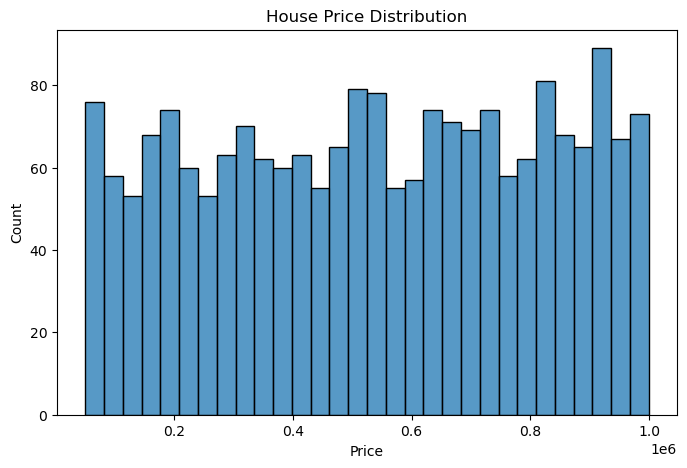

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price'], bins=30)

plt.title("House Price Distribution")

plt.show()

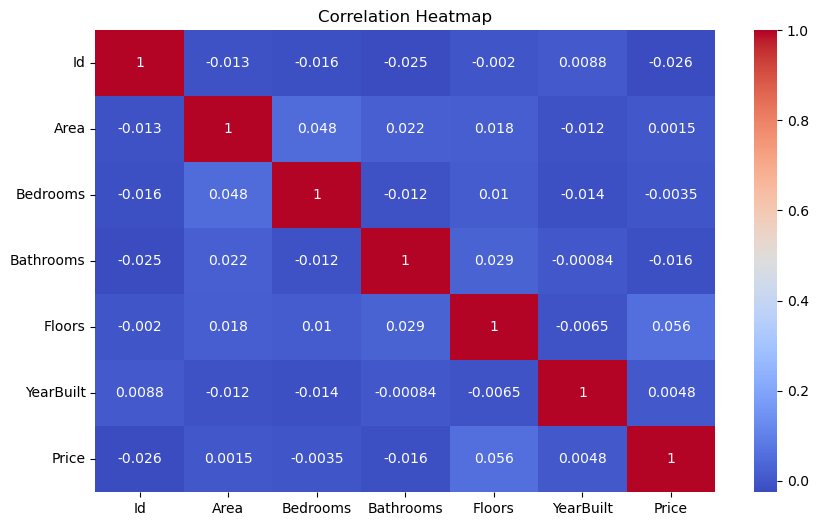

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [8]:
encoder = LabelEncoder()

df['Location'] = encoder.fit_transform(df['Location'])

df['Condition'] = encoder.fit_transform(df['Condition'])

df['Garage'] = encoder.fit_transform(df['Garage'])

In [9]:
X = df.drop(['Price', 'Id'], axis=1)

y = df['Price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
lr_predictions = lr_model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, lr_predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

Linear Regression Results
MAE: 244419.99901363705
RMSE: 280587.6374016649
R2 Score: -0.011961539273188215


In [15]:
gb_model = GradientBoostingRegressor()

gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [16]:
gb_predictions = gb_model.predict(X_test)

In [17]:
mae_gb = mean_absolute_error(y_test, gb_predictions)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, gb_predictions)
)

r2_gb = r2_score(y_test, gb_predictions)

print("Gradient Boosting Results")

print("MAE:", mae_gb)

print("RMSE:", rmse_gb)

print("R2 Score:", r2_gb)

Gradient Boosting Results
MAE: 245080.67154945724
RMSE: 283910.2485125358
R2 Score: -0.03606996074282409


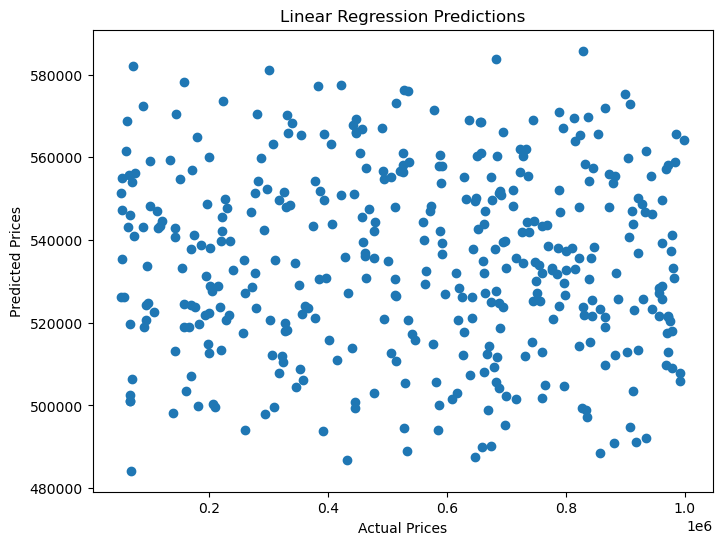

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Linear Regression Predictions")

plt.show()

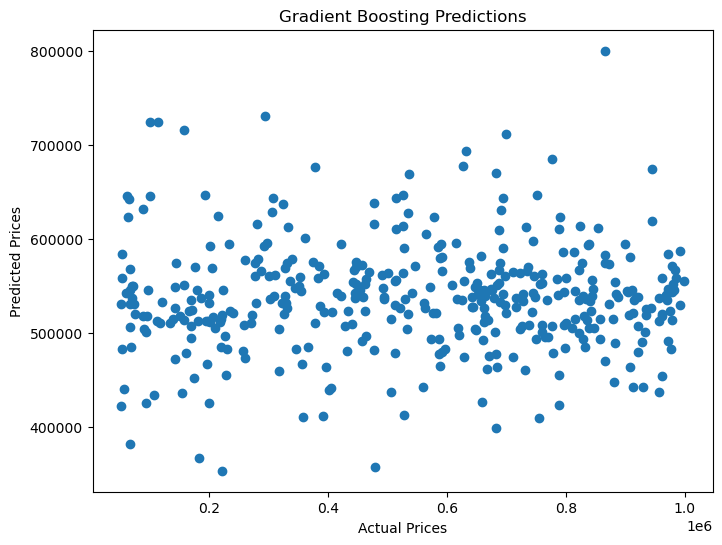

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, gb_predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Gradient Boosting Predictions")

plt.show()

In [20]:
importance = gb_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

     Feature  Importance
0       Area    0.440119
4  YearBuilt    0.213231
2  Bathrooms    0.085514
1   Bedrooms    0.083576
5   Location    0.067400
6  Condition    0.066023
3     Floors    0.038852
7     Garage    0.005284
